# SWAP-Stress: Earth Engine Covariates (toy demo around ReESH `US-CDM`)

This notebook explains the **spatial covariates** used by SWAP-Stress and demonstrates:
- Building the project feature stack (`map/data/call_ee.py`)
- Sampling + visualizing covariates in a ~4 km neighborhood around a station (ReESH example: `US-CDM`)
- Pulling thumbnails from Earth Engine into a notebook (pattern similar to `/home/dgketchum/code/openet-ptjpl/examples/single_image.ipynb`)

Important:
- Earth Engine calls use authentication and quotas. By default, this notebook does **not** call EE.
- Sentinel-2 is **not** in the current project feature stack. If shown here, it must be labeled as visualization-only.

In [ ]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import geopandas as gpd
except Exception:
    gpd = None

try:
    import ee
except Exception:
    ee = None

try:
    import requests
except Exception:
    requests = None

try:
    from PIL import Image
except Exception:
    Image = None

try:
    from IPython.display import display
except Exception:
    display = None

# -----------------------------
# Config
# -----------------------------
DATA_ROOT = os.environ.get(
    "SWAPSTRESS_DATA_ROOT",
    "/nas/soils",
)
DATA_ROOT = str(Path(DATA_ROOT).expanduser())

OUT_DIR = Path("notebooks/_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SITE_ID = os.environ.get("SWAPSTRESS_SITE_ID", "US-CDM")
BUFFER_M = int(os.environ.get("SWAPSTRESS_BUFFER_M", "4000"))
RESOLUTION_M = int(os.environ.get("SWAPSTRESS_RESOLUTION_M", "250"))
IMAGE_SIZE = int(os.environ.get("SWAPSTRESS_THUMB_SIZE", "768"))

# Guard EE/quota steps
RUN_EE = True
SHOW_SENTINEL2_QUICKLOOK = True  # visualization-only; NOT in current stack

# Manual fallback if station coordinate isn't found on disk
MANUAL_LON_LAT = None  # e.g., (-120.123, 38.456)

print("DATA_ROOT:", DATA_ROOT)
print("SITE_ID:", SITE_ID)
print("BUFFER_M:", BUFFER_M)
print("RESOLUTION_M:", RESOLUTION_M)
print("RUN_EE:", RUN_EE)

## 1) Load a ReESH station point (`US-CDM`)

This reads ReESH station locations from the standard project shapefile layout under `DATA_ROOT`.

If you don't have the shapefile locally, set `MANUAL_LON_LAT` in the config cell.

In [2]:
def _first_existing(*paths: str) -> str | None:
    for p in paths:
        if p and Path(p).exists():
            return p
    return None


reesh_shp = _first_existing(
    f"{DATA_ROOT}/soil_potential_obs/reesh/shapefile/reesh_sites_mgrs.shp",
    f"{DATA_ROOT}/soil_potential_obs/reesh/shapefile/reesh_sites_mgrs_5070.shp",
)

site_lon_lat = None

if MANUAL_LON_LAT is not None:
    site_lon_lat = tuple(MANUAL_LON_LAT)
elif gpd is None:
    print("geopandas not available and MANUAL_LON_LAT is None")
elif reesh_shp is None:
    print("ReESH shapefile not found under DATA_ROOT; set MANUAL_LON_LAT")
else:
    gdf = gpd.read_file(reesh_shp)
    if gdf.crs is None:
        gdf = gdf.set_crs(4326)
    gdf = gdf.to_crs(4326)
    if "site_id" not in gdf.columns:
        raise KeyError("Expected 'site_id' column in ReESH shapefile")
    # shapefile uses underscores (US_CDM), preprocessed files use hyphens (US-CDM)
    site_key = SITE_ID.replace("-", "_")
    row = gdf.loc[gdf["site_id"].astype(str) == site_key]
    if row.empty:
        raise KeyError(f"site_id={site_key} not found in {reesh_shp}")
    geom = row.geometry.iloc[0]
    site_lon_lat = (float(geom.x), float(geom.y))

print("reesh_shp:", reesh_shp)
print("site_lon_lat:", site_lon_lat)

reesh_shp: /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/reesh/shapefile/reesh_sites_mgrs.shp
site_lon_lat: (-109.7471, 37.5241)


## 2) Build the project feature stack (guarded)

The canonical covariate stack is defined in `map/data/call_ee.py`.

This section is guarded by `RUN_EE` to avoid accidental quota use.

In [3]:
if not RUN_EE:
    print("RUN_EE is False; skipping Earth Engine calls")
elif ee is None:
    raise ImportError("earthengine-api is not installed or import failed")
elif site_lon_lat is None:
    raise ValueError(
        "No lon/lat available; set MANUAL_LON_LAT or provide ReESH shapefile"
    )
else:
    from map.data.call_ee import stack_bands_climatology, is_authorized
    from map.data.ee_feature_list import label_feature

    is_authorized()

    lon, lat = site_lon_lat
    pt = ee.Geometry.Point([lon, lat])
    roi = pt.buffer(BUFFER_M)

    stack = stack_bands_climatology(roi, region="conus")
    bands = stack.bandNames().getInfo()

    print("Band count:", len(bands))
    for b in bands[:40]:
        print(b, "->", label_feature(b))

Authorized


/home/dgketchum/miniconda/envs/swap/lib/python3.12/site-packages/ee/deprecation.py:214: DeprecationWarning: 

Attention required for USGS/3DEP/10m! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by USGS/3DEP/10m_collection

Learn more: https://developers.google.com/earth-engine/datasets/catalog/USGS_3DEP_10m

  warnings.warn(warning, category=DeprecationWarning)


Band count: 365
B2_mean_gs -> Landsat B2 (blue) mean (growing season)
B2_stdDev_gs -> Landsat B2 (blue) std dev (growing season)
B3_mean_gs -> Landsat B3 (green) mean (growing season)
B3_stdDev_gs -> Landsat B3 (green) std dev (growing season)
B4_mean_gs -> Landsat B4 (red) mean (growing season)
B4_stdDev_gs -> Landsat B4 (red) std dev (growing season)
B5_mean_gs -> Landsat B5 (NIR) mean (growing season)
B5_stdDev_gs -> Landsat B5 (NIR) std dev (growing season)
B6_mean_gs -> Landsat B6 (SWIR1) mean (growing season)
B6_stdDev_gs -> Landsat B6 (SWIR1) std dev (growing season)
B7_mean_gs -> Landsat B7 (SWIR2) mean (growing season)
B7_stdDev_gs -> Landsat B7 (SWIR2) std dev (growing season)
B10_mean_gs -> Landsat B10 (thermal) mean (growing season)
B10_stdDev_gs -> Landsat B10 (thermal) std dev (growing season)
nd_mean_gs -> NDVI mean (growing season)
nd_stdDev_gs -> NDVI std dev (growing season)
nw_mean_gs -> NDWI mean (growing season)
nw_stdDev_gs -> NDWI std dev (growing season)
evi_mea

### 2a) Covariate groups (what's in the stack)

We classify band names using the same feature-grouping logic used in model training utilities.

In [4]:
if not RUN_EE:
    pass
else:
    from map.data.features import classify_feature

    group_counts = pd.Series([classify_feature(b) for b in bands]).value_counts()
    group_counts

### 2b) Sample band values at the station point

This is a quick join sanity check: does the stack return non-null values at the station location?

In [5]:
if not RUN_EE:
    pass
else:
    # Full stack is too heavy to sample at once; use reduceRegion on a few bands
    sample_bands = [
        b
        for b in [
            "nd_mean_gs",
            "elevation",
            "VV_mean",
            "sm_profile_mean",
            "clay",
            "slope",
        ]
        if b in bands
    ]
    if not sample_bands:
        sample_bands = bands[:6]

    preview = {}
    for b in sample_bands:
        try:
            val = (
                stack.select([b])
                .reduceRegion(
                    reducer=ee.Reducer.first(), geometry=pt, scale=RESOLUTION_M
                )
                .getInfo()
            )
            v = val.get(b)
            preview[b] = round(v, 4) if isinstance(v, float) else v
        except Exception as exc:
            preview[b] = f"error: {exc}"

    print(f"Sampled {len(preview)} bands at station point:")
    preview

Sampled 5 bands at station point:


## 3) Thumbnail helper (EE → URL → notebook display)

This follows the same overall pattern as `/home/dgketchum/code/openet-ptjpl/examples/single_image.ipynb`:
- build an EE image
- `.visualize(...)`
- `.getThumbURL(...)`
- download and display

In [6]:
from io import BytesIO


def show_thumb(url: str, title: str | None = None):
    if requests is None or Image is None:
        print("requests/PIL not available")
        print(url)
        return
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    img = Image.open(BytesIO(r.content))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(np.array(img))
    ax.axis("off")
    if title:
        ax.set_title(title)
    plt.show()

## 4) Neighborhood visualizations (examples from the current stack)

We try to visualize a few layers that are part of the current stack:
- Landsat NDVI composite (`nd_mean_gs`)
- Sentinel-1 backscatter (`VV_mean`)
- SMAP L4 profile soil moisture (`sm_profile_mean`)
- Terrain elevation (`elevation`)

If any of these band names differ (stack changes), the band discovery cell below will print candidates.

In [7]:
if not RUN_EE:
    pass
else:
    bands = stack.bandNames().getInfo()

    def find_band(patterns: list[str]) -> str | None:
        for p in patterns:
            for b in bands:
                if b == p:
                    return b
        # fallback: substring search
        for p in patterns:
            for b in bands:
                if p in b:
                    return b
        return None

    b_nd = find_band(["nd_mean_gs", "nd_mean_", "nd_"])
    b_vv = find_band(["VV_mean", "VV_"])
    b_smap = find_band(["sm_profile_mean", "sm_profile_"])
    b_elev = find_band(["elevation", "elev"])

    print("Selected bands:")
    print("  NDVI-like:", b_nd)
    print("  Sentinel-1 VV:", b_vv)
    print("  SMAP L4 sm_profile:", b_smap)
    print("  elevation:", b_elev)

    print("\nIf any are None, here are band name hints:")
    for key in ["nd", "VV", "sm_profile", "elevation"]:
        hits = [b for b in bands if key in b]
        print(key, "hits:", hits[:10])

Selected bands:
  NDVI-like: nd_mean_gs
  Sentinel-1 VV: VV_mean
  SMAP L4 sm_profile: sm_profile_mean
  elevation: elevation

If any are None, here are band name hints:
nd hits: ['nd_mean_gs', 'nd_stdDev_gs', 'nd_mean_1', 'nd_stdDev_1', 'nd_mean_2', 'nd_stdDev_2', 'nd_mean_3', 'nd_stdDev_3', 'nd_mean_4', 'nd_stdDev_4']
VV hits: ['VV_mean', 'VH_VV_mean', 'VV_stdDev', 'VH_VV_stdDev']
sm_profile hits: ['sm_profile_mean', 'sm_profile_stdDev']
elevation hits: ['elevation']


NDVI composite (Landsat)
https://earthengine.googleapis.com/v1/projects/ee-dgketchum/thumbnails/534b56e3c87e3749c8ba83b550539a12-34a5ab0e74710d109a371ce6b9356938:getPixels
Display failed: HTTPSConnectionPool(host='earthengine.googleapis.com', port=443): Read timed out. (read timeout=60)
Sentinel-1 VV mean
https://earthengine.googleapis.com/v1/projects/ee-dgketchum/thumbnails/211818b4136e819ef2e9a220ea297947-502fed819c978341342a7f9473eb2d3d:getPixels


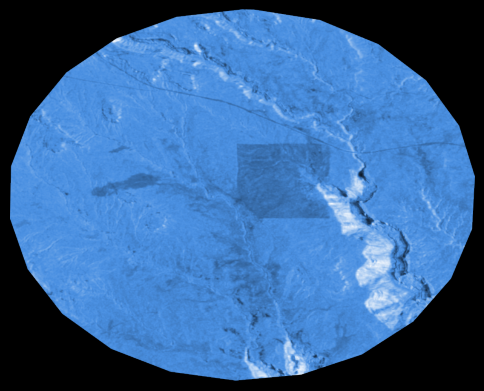

SMAP L4 sm_profile mean
https://earthengine.googleapis.com/v1/projects/ee-dgketchum/thumbnails/1ace6bb87c8fe6658d25e779be7fe964-ff6a9f0fa15685aea95dd9c146e0f691:getPixels
Display failed: HTTPSConnectionPool(host='earthengine.googleapis.com', port=443): Read timed out. (read timeout=60)
Elevation
https://earthengine.googleapis.com/v1/projects/ee-dgketchum/thumbnails/2f4b8c1f82ac4733371fafbe58de0844-fdd444e60952f29d5660daea7ac02eb8:getPixels


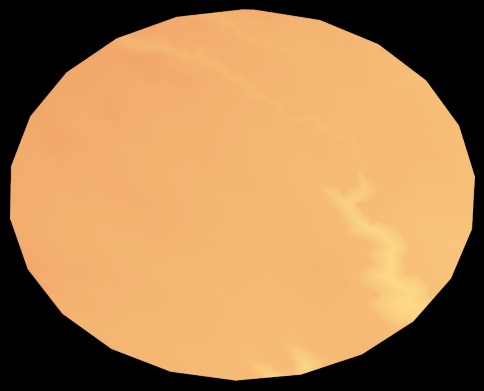

In [8]:
if not RUN_EE:
    pass
else:
    lon, lat = site_lon_lat
    region = ee.Geometry.Point([lon, lat]).buffer(BUFFER_M).bounds()

    def thumb_url(img: "ee.Image", viz: dict) -> str:
        return img.visualize(**viz).getThumbURL(
            {"region": region, "dimensions": IMAGE_SIZE}
        )

    thumbs = []
    if b_nd:
        thumbs.append(
            (
                "NDVI composite (Landsat)",
                thumb_url(
                    stack.select([b_nd]),
                    {
                        "min": -0.1,
                        "max": 0.9,
                        "palette": ["#2c7bb6", "#ffffbf", "#d7191c"],
                    },
                ),
            )
        )
    if b_vv:
        thumbs.append(
            (
                "Sentinel-1 VV mean",
                thumb_url(
                    stack.select([b_vv]),
                    {"min": -25, "max": 0, "palette": ["black", "#4a90e2", "white"]},
                ),
            )
        )
    if b_smap:
        thumbs.append(
            (
                "SMAP L4 sm_profile mean",
                thumb_url(
                    stack.select([b_smap]),
                    {
                        "min": 0.0,
                        "max": 0.5,
                        "palette": ["#440154", "#21918c", "#fde725"],
                    },
                ),
            )
        )
    if b_elev:
        thumbs.append(
            (
                "Elevation",
                thumb_url(
                    stack.select([b_elev]),
                    {
                        "min": 0,
                        "max": 3000,
                        "palette": ["#1a9850", "#fee08b", "#d73027"],
                    },
                ),
            )
        )

    for title, url in thumbs:
        print(title)
        print(url)
        try:
            show_thumb(url, title=None)
        except Exception as e:
            print("Display failed:", e)

## 5) Simple gridded neighborhood extraction (one band)

This pulls a small raster array from EE for a single band using `sampleRectangle` and plots it.

This is meant as a *sanity check* and visualization aid, not a production export.

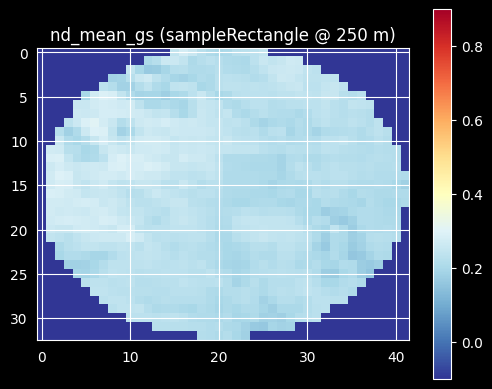

Saved: notebooks/_outputs/earth_engine_ndvi_grid.png


In [9]:
if not RUN_EE:
    pass
elif b_nd is None:
    print("No NDVI-like band selected; skipping gridded extraction")
else:
    # Keep the region small: use ROI bounds
    arr_dict = (
        stack.select([b_nd])
        .reproject(crs="EPSG:4326", scale=RESOLUTION_M)
        .sampleRectangle(
            region=region,
            defaultValue=-9999,
        )
        .getInfo()
    )
    props = arr_dict.get("properties", {})
    band_arr = np.array(props.get(b_nd, []))
    if band_arr.size == 0:
        print("Empty array returned")
    else:
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(band_arr, cmap="RdYlBu_r", vmin=-0.1, vmax=0.9)
        ax.set_title(f"{b_nd} (sampleRectangle @ {RESOLUTION_M} m)")
        fig.colorbar(im, ax=ax, shrink=0.8)
        out = OUT_DIR / "earth_engine_ndvi_grid.png"
        fig.savefig(out, dpi=200)
        plt.show()
        print("Saved:", out)

## 6) Optional: Sentinel-2 quicklook (visualization-only)

Sentinel-2 is not currently part of the SWAP-Stress covariate stack. This cell is for outreach/intuition only unless the stack is updated.

https://earthengine.googleapis.com/v1/projects/ee-dgketchum/thumbnails/6f0ab747b03dfbbb293d77360af72d70-5276d6c41904593c1bb5b96c4057245f:getPixels


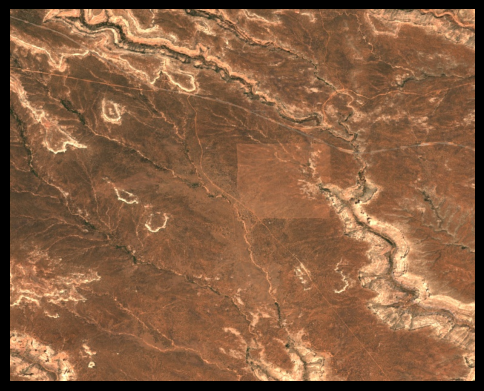

In [10]:
if not (RUN_EE and SHOW_SENTINEL2_QUICKLOOK):
    print("Skipping Sentinel-2 quicklook")
elif site_lon_lat is None:
    raise ValueError("Need site_lon_lat")
else:
    lon, lat = site_lon_lat
    region = ee.Geometry.Point([lon, lat]).buffer(BUFFER_M).bounds()
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(region)
        .filterDate("2023-06-01", "2023-09-30")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .median()
        .select(["B4", "B3", "B2"])  # RGB
    )
    url = s2.visualize(min=0, max=3000).getThumbURL(
        {"region": region, "dimensions": IMAGE_SIZE}
    )
    print(url)
    show_thumb(url)